# 02 — Baseline Model: TF-IDF + Logistic Regression

Turn words into numbers (TF-IDF with unigrams + bigrams), then a simple linear model. Fast, cheap, explainable — and it already passes the project gate **F1(negative) ≥ 0.85**.

Training is done by `src/train.py` (tracked in MLflow). Here we load the saved model and evaluate it.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `src` importable

In [2]:
import numpy as np
from src.data import load_imdb
from src.predict import load_model
from src.evaluate import evaluate_negative_class

model = load_model()
_, test_df = load_imdb()
p_negative = model.predict_proba(test_df['text'])[:, 0]
metrics = evaluate_negative_class(test_df['label'].to_numpy(), p_negative)
metrics

{'f1_negative': 0.899823264781491,
 'recall_negative': 0.89608,
 'precision_negative': 0.9035979348176831,
 'precision_at_100': 1.0,
 'precision_at_1000': 1.0,
 'passes_gate': True}

## Which words drive the decision?

A linear model is transparent: each word has a weight. Negative weights push toward the negative class.

In [3]:
import pandas as pd
vec = model.named_steps['tfidf']; clf = model.named_steps['clf']
weights = pd.Series(clf.coef_[0], index=vec.get_feature_names_out())
print('Most NEGATIVE words:'); print(weights.nsmallest(15))
print()
print('Most POSITIVE words:'); print(weights.nlargest(15))

Most NEGATIVE words:
bad         -7.908264
worst       -7.192661
awful       -5.846064
the worst   -5.739773
boring      -5.359509
poor        -4.981402
waste       -4.910802
terrible    -4.397683
nothing     -4.315747
no          -4.184159
worse       -4.020073
dull        -3.774287
stupid      -3.687594
horrible    -3.624888
poorly      -3.606379
dtype: float64

Most POSITIVE words:
great        7.081455
excellent    5.457116
wonderful    4.407879
perfect      4.382929
the best     3.889120
best         3.859733
amazing      3.727832
love         3.522681
fun          3.422936
loved        3.314713
today        3.247855
well         3.135379
favorite     2.990097
brilliant    2.955521
enjoyed      2.930067
dtype: float64


## Probability calibration

The business threshold (notebook 04) is chosen on these probabilities, so they must be honest: when the model says 80%, about 80% of those reviews should really be negative.

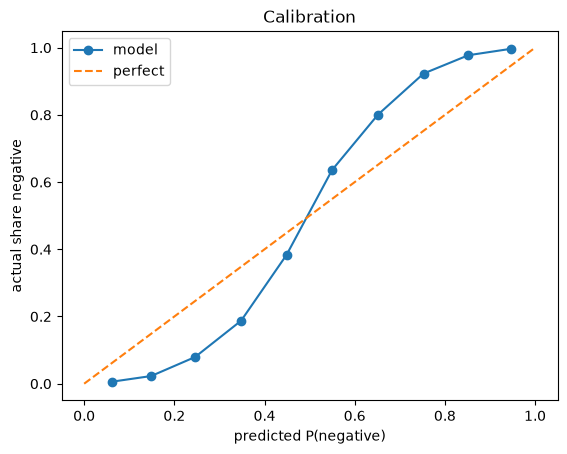

In [4]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
y_neg = (test_df['label'].to_numpy() == 0).astype(int)
frac_pos, mean_pred = calibration_curve(y_neg, p_negative, n_bins=10)
plt.plot(mean_pred, frac_pos, 'o-', label='model')
plt.plot([0, 1], [0, 1], '--', label='perfect')
plt.xlabel('predicted P(negative)'); plt.ylabel('actual share negative')
plt.legend(); plt.title('Calibration');